# Week 1 – Introduction to Vectorization

In the previous notebook, we wrote every computation with explicit Python loops.

In this notebook, we introduce **vectorization**: writing operations so they work on many numbers at once.

This notebook is not yet a full linear regression implementation. Its purpose is to prepare you for the next notebook, where we will use vectorization for prediction, cost, gradients, and gradient descent.

By the end, you should be able to:

- Understand the difference between a Python list and a NumPy array.
- Apply arithmetic operations to an entire array.
- Replace simple loops with vectorized expressions.
- Understand elementwise operations and dot products.
- See why vectorization can be faster for large datasets.


## 1. Setup


In [1]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 2. Python Lists vs NumPy Arrays

A Python list is a general container. It can store many kinds of objects.

A NumPy array is designed for numerical computation. When all values are numbers, NumPy can apply operations efficiently to the whole array.

In this notebook, we will use lists when we want to show each step explicitly, and NumPy arrays when we want to apply one operation to many numbers at once.


In [4]:
# A regular Python list.
x_list = [0, 1, 2, 3, 4]

# A NumPy array with the same values.
x_array = np.array([0, 1, 2, 3, 4])

print("Python list:", x_list)
print("NumPy array:", x_array)
print("Type of x_list:", type(x_list))
print("Type of x_array:", type(x_array))


Python list: [0, 1, 2, 3, 4]
NumPy array: [0 1 2 3 4]
Type of x_list: <class 'list'>
Type of x_array: <class 'numpy.ndarray'>


## 3. Arithmetic on Lists and Arrays

With a Python list, arithmetic does not automatically apply to each number.

With a NumPy array, arithmetic is applied **element by element**.


In [5]:
# Multiplying a Python list by 3 repeats the list.
print("x_list * 3:", x_list * 3)

# Multiplying a NumPy array by 3 multiplies each value.
print("x_array * 3:", x_array * 3)


x_list * 3: [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4]
x_array * 3: [ 0  3  6  9 12]


In [6]:
# This operation is applied to every element of the NumPy array.
y_array = 3 * x_array + 2

print("x_array:", x_array)
print("3 * x_array + 2:", y_array)


x_array: [0 1 2 3 4]
3 * x_array + 2: [ 2  5  8 11 14]


## 4. From a Loop to a Vectorized Expression

Suppose we want to compute:

$$
y = 3x + 2
$$

for several values of `x`.

First, we do it with a loop. Then we do it with NumPy.


In [7]:
# Loop version.
y_loop = []

for i in range(len(x_list)):
    y_value = 3 * x_list[i] + 2
    y_loop.append(y_value)

print("Loop result:", y_loop)


Loop result: [2, 5, 8, 11, 14]


In [8]:
# Vectorized version.
# This single line replaces the loop above.
y_vectorized = 3 * x_array + 2

print("Vectorized result:", y_vectorized)


Vectorized result: [ 2  5  8 11 14]


In [9]:
# np.allclose checks whether two numerical results are essentially the same.
# This is useful because floating-point numbers can have tiny rounding differences.
print("Do both versions match?", np.allclose(y_loop, y_vectorized))


Do both versions match? True


## 5. Elementwise Operations

When two arrays have the same shape, NumPy can combine them element by element.


In [10]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("a:", a)
print("b:", b)
print("a + b:", a + b)
print("a * b:", a * b)
print("a ** 2:", a ** 2)


a: [1 2 3 4]
b: [10 20 30 40]
a + b: [11 22 33 44]
a * b: [ 10  40  90 160]
a ** 2: [ 1  4  9 16]


## 6. Errors and Squared Errors

In regression, we often compare predictions with true target values.

Vectorization lets us compute all errors at once.


In [11]:
# Imagine these are true values and model predictions.
y_true = np.array([2, 5, 8, 11, 14])
y_pred = np.array([1, 6, 7, 10, 16])

# Each error is prediction minus true value.
errors = y_pred - y_true

# Each squared error is error squared.
squared_errors = errors ** 2

print("y_true:", y_true)
print("y_pred:", y_pred)
print("errors:", errors)
print("squared_errors:", squared_errors)
print("sum of squared errors:", np.sum(squared_errors))


y_true: [ 2  5  8 11 14]
y_pred: [ 1  6  7 10 16]
errors: [-1  1 -1 -1  2]
squared_errors: [1 1 1 1 4]
sum of squared errors: 8


## 7. Dot Product

A **dot product** multiplies matching elements and then sums the results.

For two vectors:

$$
a \cdot b = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n
$$

This is common in machine learning because many models combine features and weights.


In [12]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Loop version of the dot product.
dot_loop = 0
for i in range(len(a)):
    dot_loop = dot_loop + a[i] * b[i]

# NumPy version of the dot product.
dot_vectorized = np.dot(a, b)

print("Loop dot product:", dot_loop)
print("NumPy dot product:", dot_vectorized)


Loop dot product: 32
NumPy dot product: 32


## 8. Creating Evenly Spaced Values

In the first notebook, we created `x` values between `0` and `10` using a loop.

NumPy has a helper called `np.linspace` for this.


In [13]:
# Create 5 evenly spaced values between 0 and 10.
x_small = np.linspace(0, 10, 5)

# Create 50 evenly spaced values between 0 and 10.
x_many = np.linspace(0, 10, 50)

print("5 values:", x_small)
print("First 10 of 50 values:", x_many[:10])


5 values: [ 0.   2.5  5.   7.5 10. ]
First 10 of 50 values: [0.     0.2041 0.4082 0.6122 0.8163 1.0204 1.2245 1.4286 1.6327 1.8367]


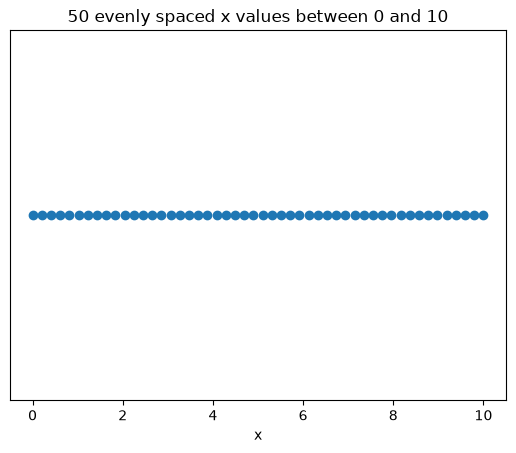

In [14]:
# Visualize the 50 x values on a simple line.
plt.figure()
plt.plot(x_many, np.zeros_like(x_many), "o")
plt.xlabel("x")
plt.title("50 evenly spaced x values between 0 and 10")
plt.yticks([])
plt.show()


## 9. Why Vectorization Can Be Faster

Python loops execute one step at a time in the Python interpreter.

NumPy operations are implemented in optimized low-level code, so they can process many values more efficiently.


In [15]:
# Create many values so the timing difference is easier to see.
large_m = 1_000_000
large_x = np.linspace(0, 10, large_m)

# Loop version: compute 3*x + 2 one value at a time.
start = time.perf_counter()
y_loop_large = []
for i in range(large_m):
    y_loop_large.append(3 * large_x[i] + 2)
loop_time = time.perf_counter() - start

# Vectorized version: compute 3*x + 2 for all values at once.
start = time.perf_counter()
y_vectorized_large = 3 * large_x + 2
vectorized_time = time.perf_counter() - start

print("Loop time:", loop_time)
print("Vectorized time:", vectorized_time)
print("Speedup:", loop_time / vectorized_time)
print("Do both versions match?", np.allclose(y_loop_large, y_vectorized_large))


Loop time: 0.4256650080005784
Vectorized time: 0.010788688000502589
Speedup: 39.45475186424419
Do both versions match? True


## 10. Summary

| Idea | Loop Version | Vectorized Version |
|------|--------------|--------------------|
| Multiply all values | loop over `x[i]` | `3 * x` |
| Add to all values | loop over `x[i]` | `x + 2` |
| Compute predictions | append one by one | `w * x + b` |
| Compute errors | loop over examples | `predictions - y` |
| Sum values | accumulate in a loop | `np.sum(values)` |
| Dot product | multiply and add in a loop | `np.dot(a, b)` |

The key idea: vectorization does not change the math. It changes how we express repeated numerical operations.


## 11. Exercises

1. Change the values in `x_array`. What happens to `3 * x_array + 2`?
2. Create a new NumPy array named `z` with values `[5, 10, 15, 20]`. Compute `z / 5`.
3. Change `y_pred` in the errors section. How do the errors and squared errors change?
4. Compute the dot product of `[2, 4, 6]` and `[1, 3, 5]` using both a loop and `np.dot`.
5. In the timing section, change `large_m` to `10_000`, `100_000`, and `1_000_000`. What happens to the speedup?


## Ejercicios de repaso

In [22]:
a = np.array([3,5,7])
b = np.array([1,2,4])

print(f"Suma entre {a} y {b} es igual a: ", a+b)
print(f"Resta entre {a} y {b}: ", a-b)
print(f"Multiplicación entre {a} y {b}: ", a*b)
print(f"producto punto entre {a} y {b}: ", np.dot(a,b))



Suma entre [3 5 7] y [1 2 4] es igual a:  [ 4  7 11]
Resta entre [3 5 7] y [1 2 4]:  [2 3 3]
Multiplicación entre [3 5 7] y [1 2 4]:  [ 3 10 28]
producto punto entre [3 5 7] y [1 2 4]:  41


In [23]:
a = np.array([2,4,6,8])
a_new = a*5
a_final = a_new + 10

print(a_final)

[20 30 40 50]


In [32]:
x = np.linspace(0,100,20)
print(x)
print("Diferencia entre dos números onsecutivos: ", x[3] - x[2])

[  0.       5.2632  10.5263  15.7895  21.0526  26.3158  31.5789  36.8421
  42.1053  47.3684  52.6316  57.8947  63.1579  68.4211  73.6842  78.9474
  84.2105  89.4737  94.7368 100.    ]
Diferencia entre dos números onsecutivos:  5.2631578947368425


In [35]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7,8,9]
])

B = np.array([
    [4,6,4],
    [3,5,1],
    [6,8,2]
])

print("suma: ", A+B)
print("Resta: ", A-B)
print("Multiplicación: ", A*B)


suma:  [[ 5  8  7]
 [ 7 10  7]
 [13 16 11]]
Resta:  [[-3 -4 -1]
 [ 1  0  5]
 [ 1  0  7]]
Multiplicación:  [[ 4 12 12]
 [12 25  6]
 [42 64 18]]


Una universidad quiere estudiar la relación entre las horas de estudio y la calificación obtenida por los estudiantes.

Los datos son:

In [57]:
def predicion_nota(hora, w, b):
    return w*hora + b


x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

x_media = np.sum(x)/len(x)
y_media = np.sum(y)/len(y)

print("Promedios de cada vector: ", x_media, y_media)

numerador = np.sum((x - x_media) * (y - y_media))
denominador = np.sum((x-x_media)**2)

w = numerador/denominador
print(w)

b = y_media - w*x_media

print(f"La ecuación es: y = {w}x + {b}")

print(f"La nota para un estudiante que estudia 6 horas es:", predicion_nota(6, w, b))






Promedios de cada vector:  3.0 4.0
0.6
La ecuación es: y = 0.6x + 2.2
La nota para un estudiante que estudia 6 horas es: 5.8
